In [1]:
import os

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

In [2]:
import datajoint as dj
import numpy as np
import matplotlib.pyplot as plt 
from datetime import datetime, timedelta

c:\Users\Organoid PC\anaconda3\envs\utah_organoids\lib\site-packages\datajoint\plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
from workflow.pipeline import ephys

[2026-02-27 16:57:24,159][INFO]: DataJoint 0.14.4 connected to judewerth@db.datajoint.com:3306


Module stfio is not installed. Make sure .abf files are converted to .pkl in Python 2.


Electrode impedance shapes both signal amplitude and noise in extracellular recordings, so it must fall within an optimal range for good data quality. If impedance is too high, thermal and environmental noise increase, small spikes can be attenuated, and impedance imbalances between channels can degrade signal‑to‑noise ratio and spike detectability. If impedance is too low, non‑biological (instrumental) noise may drop but benefits can be limited in vivo because biological noise dominates, and excessively large/rough electrodes that achieve very low impedance can increase tissue interaction, alter the sampled volume, and do not necessarily improve spike sorting quality.

Here we are looking for impedance values between 50 kΩ and 2000 kΩ.

Step 1: Define Session to Explore

In [4]:
# needed values
organoid_id = "O09"
start_time = datetime(2023, 5, 4, 4, 12, 52)

key = (ephys.EphysRawFile & f"file_time BETWEEN '{start_time}' AND '{start_time+timedelta(seconds=59)}'").fetch1("KEY")
ephys.EphysRawFile & key

file_path path to the file relative to the root directory,acq_software,file_time date and time of the file acquisition,parent_folder parent folder containing the file,"filename_prefix filename prefix, if any, excluding the datetime information"
O09-12_raw/processed_O9-12_230504_041252.rhd,Intan,2023-05-04 04:12:52,O09-12_raw,utah_organoids/inbox/O09-12_raw/processed_O9-12


In [5]:
# Insert into manual session
impedance_key = {
    **key, 
    "organoid_id": organoid_id,
}

ephys.ImpedanceFile.insert1(impedance_key, skip_duplicates=True)
ephys.ImpedanceFile & impedance_key

file_path path to the file relative to the root directory,organoid_id e.g. O17
O09-12_raw/processed_O9-12_230504_041252.rhd,O09


In [6]:
ephys.ImpedanceMeasurements.populate()

{'success_count': 1, 'error_list': []}

In [7]:
ephys.ImpedanceMeasurements.Channel & impedance_key

file_path path to the file relative to the root directory,organoid_id e.g. O17,channel_idx channel index,channel_id channel id,impedance_magnitude in Ohms,impedance_phase in Degrees
O09-12_raw/processed_O9-12_230504_041252.rhd,O09,0,A-000,861275.0,-34.576
O09-12_raw/processed_O9-12_230504_041252.rhd,O09,1,A-001,1182720.0,-38.0924
O09-12_raw/processed_O9-12_230504_041252.rhd,O09,2,A-002,1100350.0,-46.4473
O09-12_raw/processed_O9-12_230504_041252.rhd,O09,3,A-003,2026530.0,-37.7753
O09-12_raw/processed_O9-12_230504_041252.rhd,O09,4,A-004,1299100.0,-51.966
O09-12_raw/processed_O9-12_230504_041252.rhd,O09,5,A-005,1306820.0,-48.7974
O09-12_raw/processed_O9-12_230504_041252.rhd,O09,6,A-006,1338440.0,-46.0873
O09-12_raw/processed_O9-12_230504_041252.rhd,O09,7,A-007,1182430.0,-43.69
O09-12_raw/processed_O9-12_230504_041252.rhd,O09,8,A-008,1105040.0,-31.469
O09-12_raw/processed_O9-12_230504_041252.rhd,O09,9,A-009,1411660.0,-47.3605


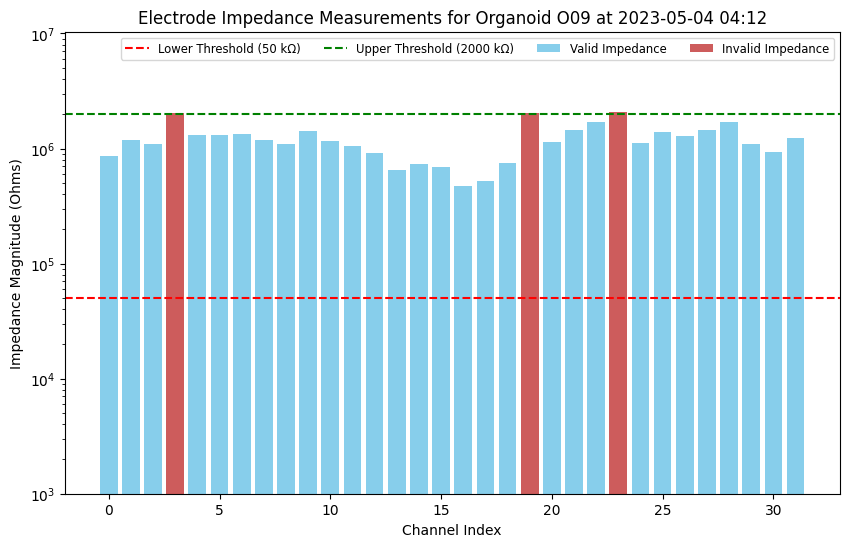

In [10]:
# Plot electrode impedances
I1 = 50000 # Ohms
I2 = 2000000 # Ohms

# fetch impedance measurements
channel_indices, impedance_magnitudes = (ephys.ImpedanceMeasurements.Channel & impedance_key).fetch("channel_idx", "impedance_magnitude")
bounds_mask = (I1 <= impedance_magnitudes) & (impedance_magnitudes <= I2)

# plot (channels within bounds are blue, out of bounds are red)
plt.figure(figsize=(10, 6))
plt.bar(channel_indices[bounds_mask], impedance_magnitudes[bounds_mask], color='skyblue', label='Valid Impedance')
plt.bar(channel_indices[~bounds_mask], impedance_magnitudes[~bounds_mask], color='indianred', label='Invalid Impedance')

plt.axhline(y=I1, color='r', linestyle='--', label='Lower Threshold (50 kΩ)')
plt.axhline(y=I2, color='g', linestyle='--', label='Upper Threshold (2000 kΩ)')
plt.yscale('log')
plt.ylim([1000, np.max(impedance_magnitudes)*5])
plt.xlabel('Channel Index')
plt.ylabel('Impedance Magnitude (Ohms)')
plt.title(f'Electrode Impedance Measurements for Organoid {impedance_key["organoid_id"]} at {start_time.strftime("%Y-%m-%d %H:%M")}')
plt.legend(loc='upper right', ncol=4, fontsize='small')

plt.show()